# Synthetic Respondent Generation using CTGAN

This notebook demonstrates how synthetic survey respondents can be generated using the CTGAN model from the SDV library.

## Table of Contents

1. Load Dataset  
2. Exploratory Data Analysis  
3. Metadata Detection  
4. Train CTGAN Model  
5. Generate Synthetic Respondents  
6. Evaluate Synthetic Data  
7. Save Synthetic Dataset

In [1]:
import warnings
warnings.filterwarnings("ignore")

## 1. Load Dataset

In [2]:
import pandas as pd

data = pd.read_csv("../datasets/airline-passenger-satisfaction/train.csv")

data.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


## 2. Exploratory Data Analysis

In [3]:
data.shape

(103904, 25)

In [4]:
data.columns

Index(['Unnamed: 0', 'id', 'Gender', 'Customer Type', 'Age', 'Type of Travel',
       'Class', 'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Inflight service',
       'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes',
       'satisfaction'],
      dtype='object')

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         103904 non-null  int64  
 1   id                                 103904 non-null  int64  
 2   Gender                             103904 non-null  object 
 3   Customer Type                      103904 non-null  object 
 4   Age                                103904 non-null  int64  
 5   Type of Travel                     103904 non-null  object 
 6   Class                              103904 non-null  object 
 7   Flight Distance                    103904 non-null  int64  
 8   Inflight wifi service              103904 non-null  int64  
 9   Departure/Arrival time convenient  103904 non-null  int64  
 10  Ease of Online booking             103904 non-null  int64  
 11  Gate location                      1039

In [6]:
data.describe()

,Unnamed: 0,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103594.000000
mean,51951.500000,64924.210502,39.379706,1189.448375,2.729683,3.060296,2.756901,2.976883,3.202129,3.250375,3.439396,3.358158,3.382363,3.351055,3.631833,3.304290,3.640428,3.286351,14.815618,15.178678
std,29994.645522,37463.812252,15.114964,997.147281,1.327829,1.525075,1.398929,1.277621,1.329533,1.349509,1.319088,1.332991,1.288354,1.315605,1.180903,1.265396,1.175663,1.312273,38.230901,38.698682
min,0.000000,1.000000,7.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,25975.750000,32533.750000,27.000000,414.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,51951.500000,64856.500000,40.000000,843.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,0.000000,0.000000
75%,77927.250000,97368.250000,51.000000,1743.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,103903.000000,129880.000000,85.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000


In [7]:
data.isnull().sum()

Unnamed: 0                             0
id                                     0
Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Inflight wifi service                  0
Departure/Arrival time convenient      0
Ease of Online booking                 0
Gate location                          0
Food and drink                         0
Online boarding                        0
Seat comfort                           0
Inflight entertainment                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Inflight service                       0
Cleanliness                            0
Departure Delay in Minutes             0
Arrival Delay in Minutes             310
satisfaction    

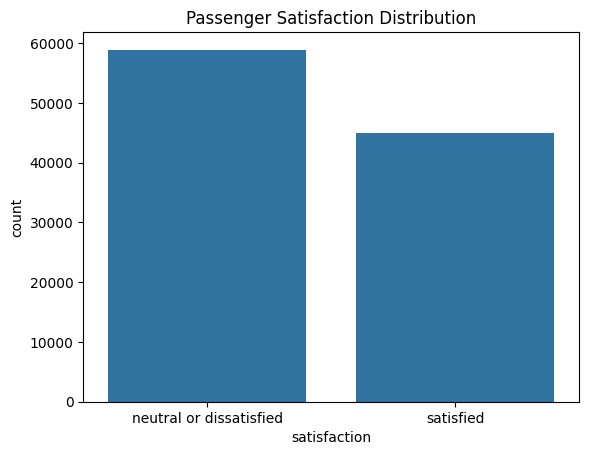

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="satisfaction", data=data)

plt.title("Passenger Satisfaction Distribution")
plt.show()

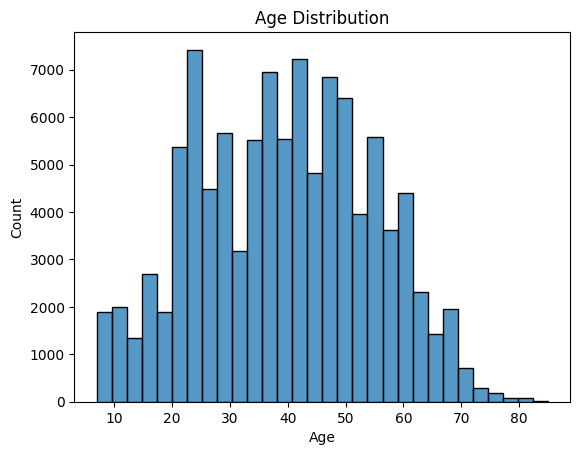

In [9]:
sns.histplot(data["Age"], bins=30)

plt.title("Age Distribution")
plt.show()

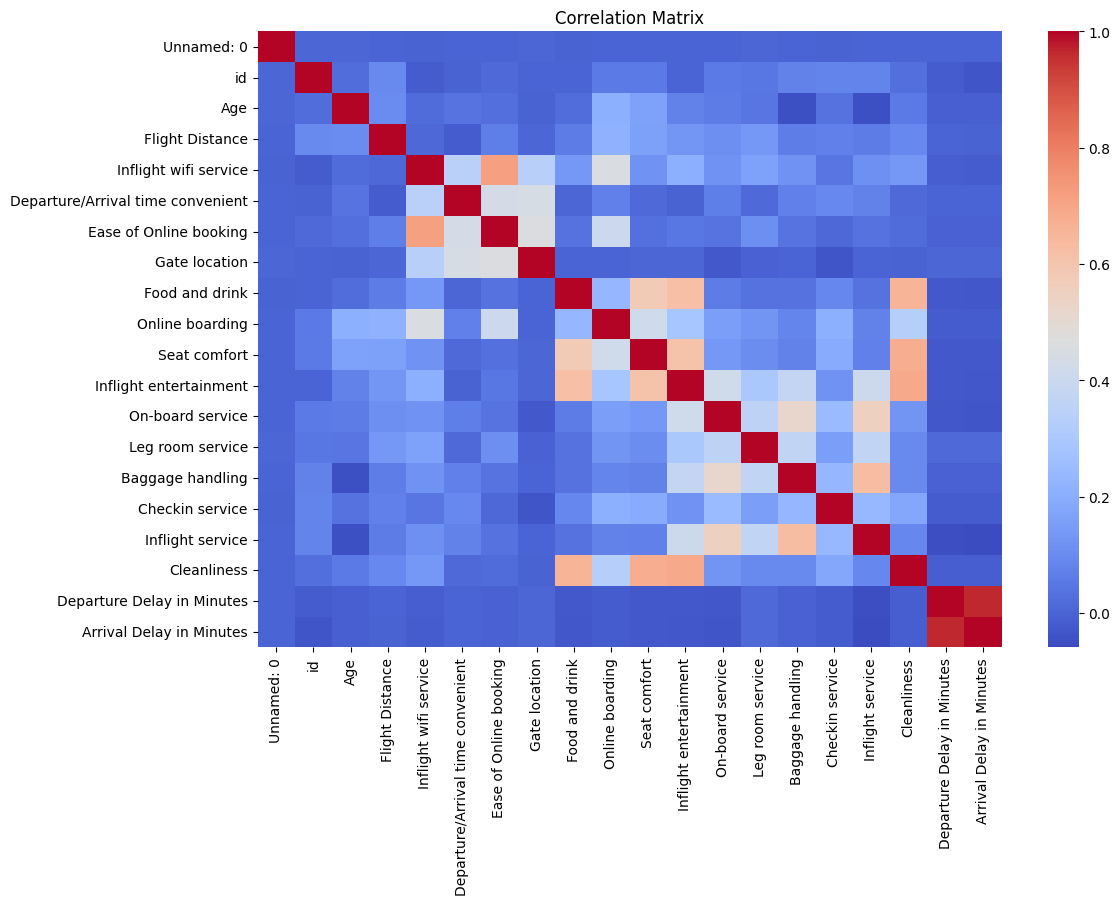

In [10]:
numeric_data = data.select_dtypes(include=["int64", "float64"])

corr = numeric_data.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm")

plt.title("Correlation Matrix")
plt.show()

In [11]:
data.to_csv("../datasets/clean_airline_data.csv", index=False)

## 3. Metadata Detection

In [12]:
from sdv.single_table import CTGANSynthesizer
from sdv.metadata import SingleTableMetadata

In [13]:
metadata = SingleTableMetadata()

metadata.detect_from_dataframe(data)

## 4. Train CTGAN Model

In [14]:
from sdv.single_table import CTGANSynthesizer

model = CTGANSynthesizer(metadata)
model.fit(data)

In [15]:
model.fit(data)

## 5. Generate Synthetic Respondents

In [16]:
synthetic_data = model.sample(10000)

synthetic_data.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,8970884,108705,Female,Loyal Customer,56,Business travel,Business,2818,1,1,...,4,4,4,4,4,4,3,2,4.0,satisfied
1,3143223,7354,Male,Loyal Customer,48,Business travel,Business,2911,4,4,...,4,4,5,5,3,5,4,0,0.0,satisfied
2,10810119,107228,Female,Loyal Customer,60,Business travel,Business,2514,3,3,...,5,5,5,3,5,5,5,9,12.0,satisfied
3,7748627,90220,Female,Loyal Customer,43,Personal Travel,Eco,369,2,5,...,3,3,3,4,5,2,3,83,9.0,neutral or dissatisfied
4,915797,48626,Female,Loyal Customer,28,Personal Travel,Eco,555,1,4,...,3,3,1,3,3,3,2,0,32.0,neutral or dissatisfied


## 6. Evaluate Synthetic Data

In [17]:
from sdv.evaluation.single_table import evaluate_quality

evaluate_quality(data, synthetic_data, metadata)

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 25/25 [00:00<00:00, 144.56it/s]|
Column Shapes Score: 92.7%

(2/2) Evaluating Column Pair Trends: |██████████| 300/300 [00:01<00:00, 209.12it/s]|
Column Pair Trends Score: 88.42%

Overall Score (Average): 90.56%



## 7. Save Synthetic Dataset

In [18]:
synthetic_data.to_csv("../synthetic_data/synthetic_airline_data.csv", index=False)

## 8. Distribution Comparison (Real vs Synthetic)

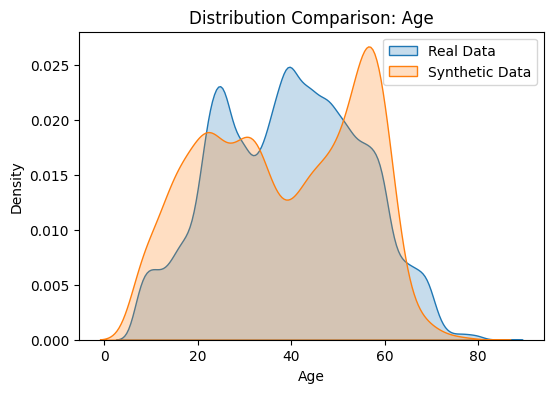

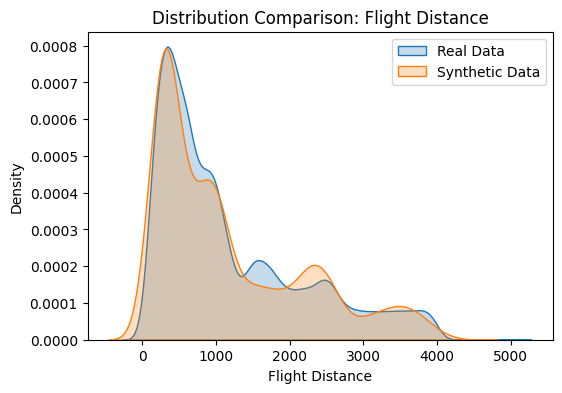

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# choose a few important variables
columns_to_compare = ["Age", "Flight Distance"]

for col in columns_to_compare:
    plt.figure(figsize=(6,4))
    
    sns.kdeplot(data[col], label="Real Data", fill=True)
    sns.kdeplot(synthetic_data[col], label="Synthetic Data", fill=True)
    
    plt.title(f"Distribution Comparison: {col}")
    plt.legend()
    plt.show()

## 9. Correlation Comparison

In [20]:
real_corr = data.corr(numeric_only=True)
synthetic_corr = synthetic_data.corr(numeric_only=True)

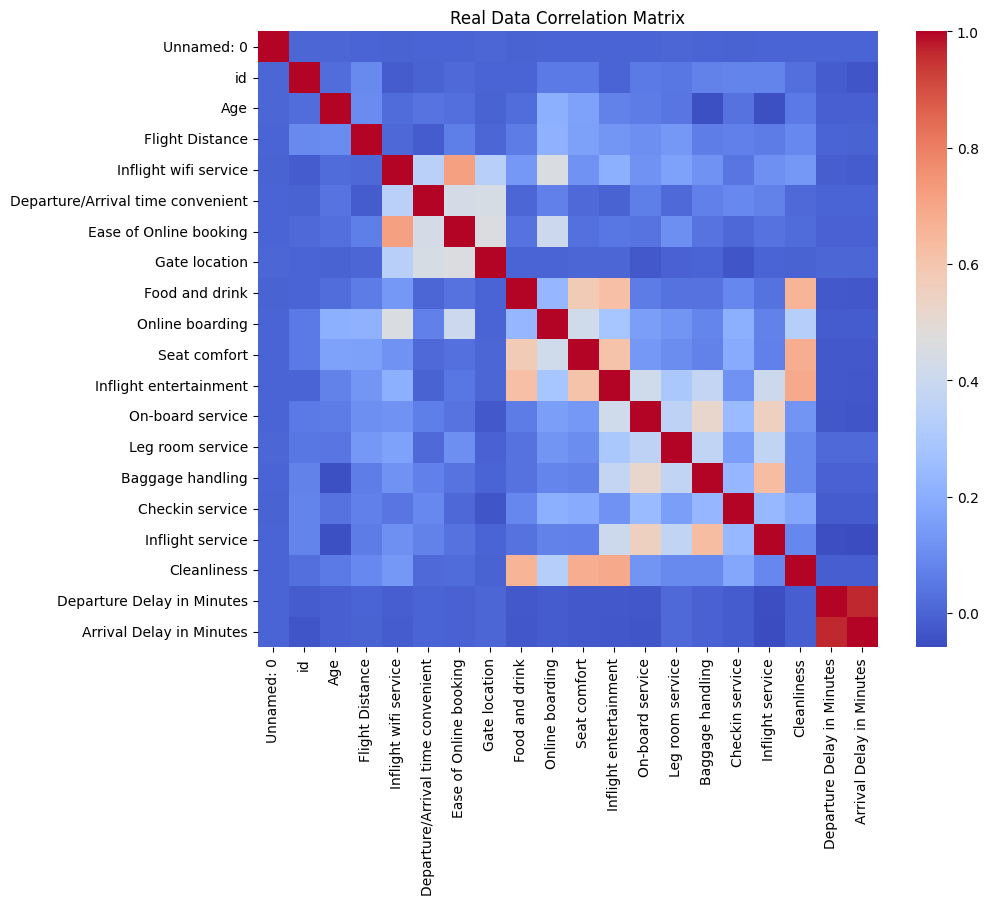

In [21]:
plt.figure(figsize=(10,8))
sns.heatmap(real_corr, cmap="coolwarm")

plt.title("Real Data Correlation Matrix")
plt.show()

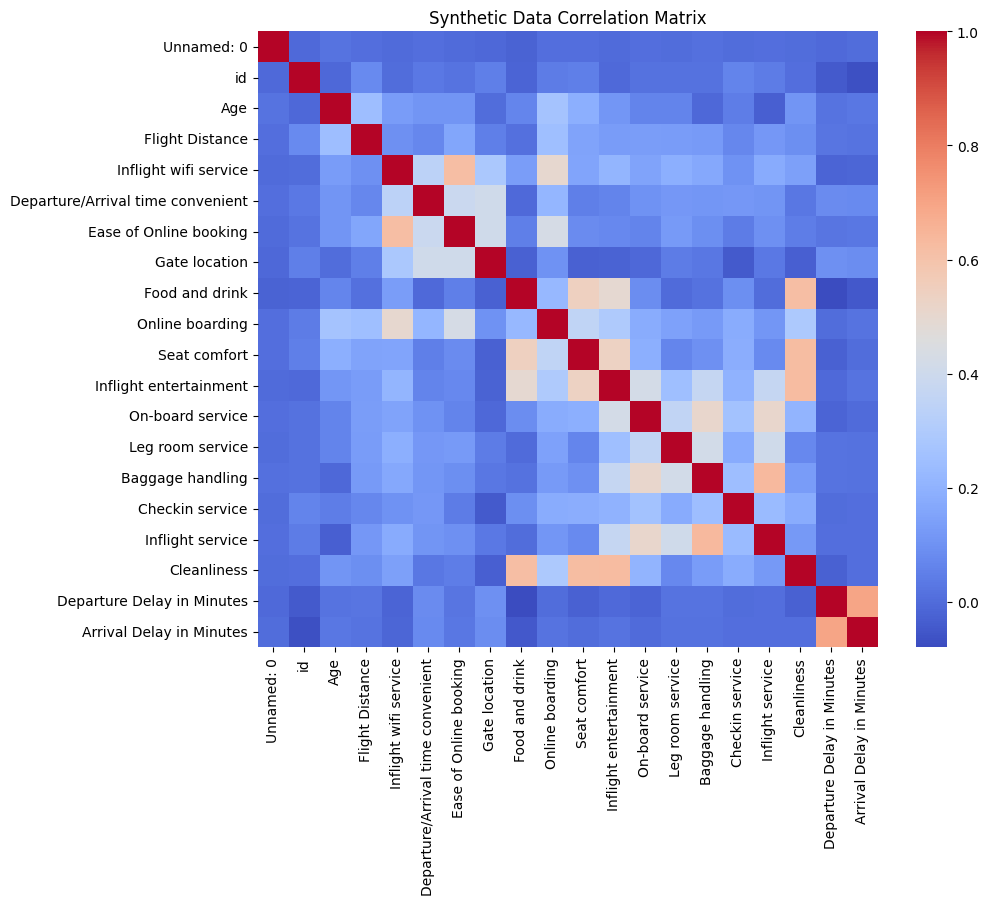

In [22]:
plt.figure(figsize=(10,8))
sns.heatmap(synthetic_corr, cmap="coolwarm")

plt.title("Synthetic Data Correlation Matrix")
plt.show()